# 31: the certified reference datasets

Real records with a documented right answer, so the read is against ground truth rather than
against another fit. Claims:

1. On the NIST StRD nonlinear-regression corpus, fitted from both of NIST's own starting
   values, the Legendre image's error falls toward the certified parameters as its order
   rises, on every dataset where the record holds enough observations for that order (the
   block image is not held to this: it moves the wrong way with order on MGH17 and DanWood,
   see below). scipy's curve_fit, the NLLS baseline throughout this notebook, diverges (more
   than 100 percent off) on two of the ten from the far start (Start 1); the image method's
   default order is too large for those two records and guards there rather than returning a
   number, though a fixed order short of the default recovers both tightly at the top of the
   buildable range. False if curve_fit is not clearly worse on the two, or if a converged
   image row is ever the wrong answer there.
2. On three short, non-uniformly sampled records, the Legendre image's error falls steadily as
   its order grows; the block image's does not track it down at the same rate. This is the
   unfavourable case for the block basis. False if block keeps pace with Legendre as order
   grows on any of the three.
3. Fitted on the first 65 percent of a record and forecast onto the held-out tail, the
   Legendre image lands within about a factor of two of NLLS started from the same point (the
   block image is checked too, and is not held to this bound). False if the Legendre forecast
   is routinely much worse than NLLS on the records where both converge.
4. On the Puromycin enzyme-kinetics data, whose design repeats each substrate concentration
   (zero spacing between a replicate pair), both images recover Vmax and Km close to NLLS: the
   discrete image evaluates a basis at each sample position and does not care whether that
   position repeats. False if either image's Vmax or Km lands far from the NLLS reference.
5. On two real series with no certified answer (COVID-19 Ukraine's early growth, the 2014-15
   hryvnia depreciation), the three methods recover close to the same rate from the same
   exponential model - the only evidence available where there is no ground truth. False if the
   three methods disagree substantially or fit poorly.

In [1]:
import os
import time
import warnings

import numpy as np
import pandas as pd
import sympy as sp
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from dtfit import fit, order_for, Original
from dtfit_experimental.study import notebook, paths, reference

STARTED = time.time()
QUICK = os.environ.get("DTFIT_QUICK") == "1"
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_rows", None)
notebook.plain_warnings()

#: The order sweeps fit below the order the model's sensitivities need on purpose, and dtfit
#: warns once per such fit.
warnings.filterwarnings("ignore", message="image coverage")

ALL_DATASETS = [name for name, _ in reference.datasets()]
DATASET_NAMES = ["Misra1a", "Chwirut2", "MGH17", "BoxBOD"] if QUICK else ALL_DATASETS
STARTS = ["start2"] if QUICK else ["start1", "start2"]
NIST_DIR = paths.data_dir() / "nist"
print(f"QUICK={QUICK} datasets={DATASET_NAMES} starts={STARTS}")


def pct_error(est, certified):
    # elementwise absolute percent error of est against certified, both
    # array-like in the same parameter order
    est = np.asarray(est, dtype=float)
    certified = np.asarray(certified, dtype=float)
    return np.abs(est - certified) / np.abs(certified) * 100.0


def in_sample_r2(y, pred):
    y = np.asarray(y, dtype=float)
    pred = np.asarray(pred, dtype=float)
    ss_res = np.sum((y - pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return float(1.0 - ss_res / ss_tot)

QUICK=False datasets=['Misra1a', 'DanWood', 'Chwirut2', 'Misra1c', 'Roszman1', 'MGH17', 'Rat42', 'BoxBOD', 'Eckerle4', 'MGH10'] starts=['start1', 'start2']


## 1. NIST StRD: parameter error against the certified values

Ten datasets, both of NIST's starting values, fitted with the Legendre and block images at
`order_for` and at twice that (each computed from the start being fitted, the way
`dtfit.fit` itself picks a default order from `p0`), and with SciPy `curve_fit` (NLLS) from
the same start. The seed is built as a `{name: value}` mapping and the fit is read back
through `FittingResult.params`, never positionally: `dtfit.fit` returns a symbolic model's
coefficients in sorted-name order regardless of the order they were declared in.


In [2]:
rows = []
if not NIST_DIR.is_dir():
    print(f"NIST corpus missing, skipping: {NIST_DIR}")
    per_dataset = pd.DataFrame()
else:
    for name in DATASET_NAMES:
        d = reference.load(name)
        canon = sorted(d.names)
        for start_label, start_vals in (("start1", d.start1), ("start2", d.start2)):
            if start_label not in STARTS:
                continue
            p0 = dict(zip(d.names, start_vals))
            domain = (float(d.x.min()), float(d.x.max()))
            k0 = order_for(d.expr, [p0[n] for n in canon], domain, var="x")

            f_num = sp.lambdify(
                (sp.Symbol("x"), *[sp.Symbol(n) for n in d.names]), d.expr, "numpy"
            )
            try:
                popt, _ = curve_fit(
                    f_num, d.x, d.y, p0=[p0[n] for n in d.names], maxfev=20000
                )
                errs = pct_error(popt, d.certified)
                status = "diverged" if errs.max() > 100.0 else "converged"
                rows.append({"dataset": name, "level": d.level, "start": start_label,
                             "method": "nlls", "order": np.nan,
                             "max_error_pct": errs.max(), "mean_error_pct": errs.mean(),
                             "status": status})
            except RuntimeError:
                rows.append({"dataset": name, "level": d.level, "start": start_label,
                             "method": "nlls", "order": np.nan,
                             "max_error_pct": np.nan, "mean_error_pct": np.nan,
                             "status": "diverged"})

            original = Original(d.x, d.y, domain=domain)
            for basis in ("legendre", "block"):
                for order in (k0, 2 * k0):
                    try:
                        res = fit(d.expr, original, var="x", basis=basis, order=order, p0=p0)
                    except ValueError:
                        rows.append({"dataset": name, "level": d.level,
                                     "start": start_label, "method": basis,
                                     "order": order, "max_error_pct": np.nan,
                                     "mean_error_pct": np.nan, "status": "guard"})
                        continue
                    est = res.params
                    errs = pct_error([est[n] for n in d.names], d.certified)
                    status = "diverged" if errs.max() > 100.0 else "converged"
                    rows.append({"dataset": name, "level": d.level,
                                 "start": start_label, "method": basis, "order": order,
                                 "max_error_pct": errs.max(),
                                 "mean_error_pct": errs.mean(), "status": status})
    per_dataset = pd.DataFrame(rows)
per_dataset


,dataset,level,start,method,order,max_error_pct,mean_error_pct,status
0,Misra1a,lower,start1,nlls,NaN,5.860549e-07,5.448226e-07,converged
1,Misra1a,lower,start1,legendre,1.0,2.118425e+00,1.945576e+00,converged
2,Misra1a,lower,start1,legendre,2.0,8.480171e-02,7.871502e-02,converged
3,Misra1a,lower,start1,block,1.0,NaN,NaN,guard
4,Misra1a,lower,start1,block,2.0,3.197364e+00,2.932782e+00,converged
5,Misra1a,lower,start2,nlls,NaN,2.170580e-07,2.009773e-07,converged
6,Misra1a,lower,start2,legendre,2.0,8.480172e-02,7.871503e-02,converged
7,Misra1a,lower,start2,legendre,4.0,2.565054e-05,2.380672e-05,converged
8,Misra1a,lower,start2,block,2.0,3.197364e+00,2.932782e+00,converged
9,Misra1a,lower,start2,block,4.0,7.894993e-01,7.322789e-01,converged


In [3]:
if QUICK or per_dataset.empty:
    print("QUICK or no data: skipping the CSV export")
else:
    notebook.save_table("31_reference_datasets", "nist_per_dataset", per_dataset)
    print("wrote experiments/results/31_reference_datasets/nist_per_dataset.csv")


wrote experiments/results/31_reference_datasets/nist_per_dataset.csv


In [4]:
if not per_dataset.empty:
    nlls_s1 = per_dataset[(per_dataset.method == "nlls") & (per_dataset.start == "start1")]
    hard = {"MGH17", "BoxBOD"} & set(nlls_s1.dataset)
    easy = set(nlls_s1.dataset) - hard
    if hard:
        hard_err = nlls_s1[nlls_s1.dataset.isin(hard)].set_index("dataset").max_error_pct
        # fails if the far start does not push NLLS past 100 percent on the hard datasets
        assert (hard_err > 100.0).all()
        image_hard = per_dataset[
            per_dataset.method.isin(["legendre", "block"])
            & (per_dataset.start == "start1") & per_dataset.dataset.isin(hard)
        ]
        # fails if an image row there finishes more than 100 percent off instead of
        # refusing: at its own default order the core must guard, never answer at all
        assert (image_hard.status != "diverged").all()
        conv_hard = image_hard[image_hard.status == "converged"]
        # fails if a converged image row there is the wrong answer, the falsifier claim 1
        # states; no row reaches it today, every one guards
        assert (conv_hard.max_error_pct < 1.0).all()
    if easy:
        easy_err = nlls_s1[nlls_s1.dataset.isin(easy)].max_error_pct
        # fails if NLLS does not converge tightly on the datasets it is known to handle
        assert (easy_err < 1e-3).all()

    block_worse = []
    images = per_dataset[per_dataset.method.isin(["legendre", "block"])]
    for method, group in images.groupby("method"):
        for (name, start), g in group.groupby(["dataset", "start"]):
            conv = g.sort_values("order")
            conv = conv[conv.status == "converged"]
            if len(conv) < 2:
                continue
            lo, hi = conv.max_error_pct.iloc[0], conv.max_error_pct.iloc[-1]
            if method == "legendre":
                # fails if legendre's error at twice order_for is not below its error
                # at order_for, on any dataset and start where both converge
                assert hi < lo, (name, start)
            elif hi >= lo:
                block_worse.append((name, start, lo, hi))

    print(f"NLLS from Start 1: {dict(zip(nlls_s1.dataset, nlls_s1.max_error_pct.round(6)))}")
    if hard:
        print(f"on {sorted(hard)} it is above 100 percent; the image method's own default "
              f"order guards there instead of reporting a wrong answer: "
              f"{image_hard[['dataset', 'method', 'order', 'status']].to_dict('records')}")
    print(f"legendre's error falls from order_for to twice order_for on every dataset and "
          f"start where both converge; block does not on: {block_worse}")

NLLS from Start 1: {'Misra1a': 1e-06, 'DanWood': 1e-06, 'Chwirut2': 6.7e-05, 'Misra1c': 0.0, 'Roszman1': 0.000248, 'MGH17': 13218.769628, 'Rat42': 1.7e-05, 'BoxBOD': 20174.362718, 'Eckerle4': 6e-06, 'MGH10': 9e-06}
on ['BoxBOD', 'MGH17'] it is above 100 percent; the image method's own default order guards there instead of reporting a wrong answer: [{'dataset': 'MGH17', 'method': 'legendre', 'order': 60.0, 'status': 'guard'}, {'dataset': 'MGH17', 'method': 'legendre', 'order': 120.0, 'status': 'guard'}, {'dataset': 'MGH17', 'method': 'block', 'order': 60.0, 'status': 'guard'}, {'dataset': 'MGH17', 'method': 'block', 'order': 120.0, 'status': 'guard'}, {'dataset': 'BoxBOD', 'method': 'legendre', 'order': 6.0, 'status': 'guard'}, {'dataset': 'BoxBOD', 'method': 'legendre', 'order': 12.0, 'status': 'guard'}, {'dataset': 'BoxBOD', 'method': 'block', 'order': 6.0, 'status': 'guard'}, {'dataset': 'BoxBOD', 'method': 'block', 'order': 12.0, 'status': 'guard'}]
legendre's error falls from order

In [5]:
if not per_dataset.empty:
    images = per_dataset[per_dataset.method.isin(["legendre", "block"])]
    pairs = []
    for (name, start), g in images.groupby(["dataset", "start"]):
        for label, order in (("order_for", g.order.min()), ("twice order_for", g.order.max())):
            leg = g[(g.method == "legendre") & (g.order == order)].iloc[0]
            blk = g[(g.method == "block") & (g.order == order)].iloc[0]
            pairs.append({"dataset": name, "start": start, "at": label, "order": order,
                          "legendre": leg.status, "block": blk.status,
                          "block_over_legendre": blk.max_error_pct / leg.max_error_pct})
    pairs = pd.DataFrame(pairs)

    def named(sub):
        return sorted(f"{r.dataset} {r.start}" for r in sub.itertuples())

    for label, g in pairs.groupby("at", sort=False):
        both = g[(g.legendre != "guard") & (g.block != "guard")]
        lo = both.loc[both.block_over_legendre.idxmin()]
        hi = both.loc[both.block_over_legendre.idxmax()]
        print(f"at {label}: both bases build on {len(both)} of {len(g)} dataset and start "
              f"pairs; block/legendre error from {lo.block_over_legendre:.2f}x "
              f"({lo.dataset} {lo.start}) to {hi.block_over_legendre:.3g}x "
              f"({hi.dataset} {hi.start})")
        print(f"  block answers alone on {named(g[(g.legendre == 'guard') & (g.block != 'guard')])}; "
              f"legendre alone on {named(g[(g.block == 'guard') & (g.legendre != 'guard')])}; "
              f"both guard on {named(g[(g.legendre == 'guard') & (g.block == 'guard')])}")

at order_for: both bases build on 13 of 20 dataset and start pairs; block/legendre error from 0.53x (Eckerle4 start1) to 152x (Roszman1 start1)
  block answers alone on ['BoxBOD start2', 'Eckerle4 start2']; legendre alone on ['MGH10 start1', 'Misra1a start1', 'Misra1c start1']; both guard on ['BoxBOD start1', 'MGH17 start1']
at twice order_for: both bases build on 14 of 20 dataset and start pairs; block/legendre error from 19.53x (Eckerle4 start1) to 2.46e+06x (DanWood start2)
  block answers alone on []; legendre alone on []; both guard on ['BoxBOD start1', 'BoxBOD start2', 'Eckerle4 start2', 'MGH17 start1', 'Rat42 start1', 'Rat42 start2']


curve_fit (the NLLS baseline throughout this notebook) diverges on two of the ten from
Start 1: 1.3e4 percent off on MGH17, 2.0e4 percent on BoxBOD. On the other eight it is under
1e-3 percent from either start. The image method does not silently do better on the two hard
ones at its own default order: computed from that same far start, the order is too large for
the record (MGH17 asks for order 60 on 33 observations, BoxBOD order 6 on 6) and the core
refuses to build it - `status="guard"` on every image row at Start 1 for both datasets, never
a wrong "converged". From the reliable Start 2 the image does recover them: Legendre reaches
1.8e-4 percent on MGH17 at twice `order_for`, and on BoxBOD neither automatic order fits six
points for Legendre (guard at both orders and both starts) while block reaches 0.19 percent at
`order_for`. What curve_fit's own divergence means on the two hard ones from Start 1 is not the
same story twice, and the next cells measure it rather than asserting it.

Where Legendre builds, its error at twice `order_for` ranges from 4.6e-7 percent (DanWood from
Start 2) up to 0.22 percent (MGH10 from Start 1). The two bases guard on different rows rather
than one covering for the other: at `order_for` both build on 13 of the 20 dataset and start
pairs, block answers where Legendre guards on two (BoxBOD and Eckerle4 from Start 2), Legendre
answers where block guards on three (MGH10, Misra1a and Misra1c from Start 1), and on two
(BoxBOD and MGH17 from Start 1) both refuse. Where both build at `order_for`, block runs from
0.53x Legendre's error (Eckerle4 from Start 1, the one pair where block is the better of the
two) to 152x (Roszman1 from Start 1, the only image row in the table above 100 percent). At
twice `order_for` both build on 14 pairs and that ratio runs from 19.5x (Eckerle4 from
Start 1) to 2.46e6 (DanWood from Start 2): the two bases are not interchangeable substitutes, and the
size of the gap depends on how far past `order_for` either is pushed.

### The two hard datasets from Start 1: artifact against real divergence

The image method's own `order_for` default guards on both, which leaves open whether it could
have recovered MGH17 and BoxBOD from Start 1 at all, and whether curve_fit's reported
divergence is a genuine wrong optimum or an artifact of that one solver call. Both are measured
directly. curve_fit without bounds is MINPACK Levenberg-Marquardt, so the same residual and the
same start go through `scipy.optimize.least_squares` with that same LM core and with its two
trust-region algorithms (`trf`, `dogbox`), each row carrying the evaluations it spent, the
residual cost it stopped at and NIST's certified cost for that record. Legendre is then fit at
every order the record allows, the automatic rule bypassed, so the favourable and unfavourable
orders are in one table.

In [6]:
hard_solvers = pd.DataFrame()
hard_range = pd.DataFrame()
if not per_dataset.empty and hard:
    from scipy.optimize import least_squares

    solver_rows = []
    range_rows = []
    for name in sorted(hard):
        d = reference.load(name)
        p0 = dict(zip(d.names, d.start1))
        f_num = sp.lambdify(
            (sp.Symbol("x"), *[sp.Symbol(n) for n in d.names]), d.expr, "numpy"
        )
        p0v = [p0[n] for n in d.names]
        cert_cost = d.residual_sum_of_squares / 2.0

        def resid(p, f_num=f_num, d=d):
            return f_num(d.x, *p) - d.y

        def point(p, d=d):
            return " ".join(f"{n}={v:.4f}" for n, v in zip(d.names, p))

        popt, _, info, _, _ = curve_fit(
            f_num, d.x, d.y, p0=p0v, maxfev=20000, full_output=True
        )
        solver_rows.append({"dataset": name, "solver": "curve_fit (lm)",
                            "max_error_pct": pct_error(popt, d.certified).max(),
                            "nfev": info["nfev"],
                            "cost": 0.5 * float(np.sum(resid(popt) ** 2)),
                            "certified_cost": cert_cost, "min_abs_grad": np.nan,
                            "point": point(popt)})
        for method in ("lm", "trf", "dogbox"):
            ls = least_squares(resid, p0v, method=method, max_nfev=20000)
            solver_rows.append({"dataset": name, "solver": f"least_squares ({method})",
                                "max_error_pct": pct_error(ls.x, d.certified).max(),
                                "nfev": ls.nfev, "cost": float(ls.cost),
                                "certified_cost": cert_cost,
                                "min_abs_grad": float(np.abs(ls.grad).min()),
                                "point": point(ls.x)})

        domain = (float(d.x.min()), float(d.x.max()))
        original = Original(d.x, d.y, domain=domain)
        # every order the record allows: an image at order K needs K + 2 samples
        for order in range(1, d.x.size - 1):
            try:
                res = fit(d.expr, original, var="x", basis="legendre", order=order, p0=p0)
            except ValueError:
                range_rows.append({"dataset": name, "order": order,
                                   "max_error_pct": np.nan, "status": "guard"})
                continue
            err = pct_error([res.params[n] for n in d.names], d.certified).max()
            range_rows.append({"dataset": name, "order": order, "max_error_pct": err,
                               "status": "diverged" if err > 100.0 else "converged"})
    hard_solvers = pd.DataFrame(solver_rows)
    hard_range = pd.DataFrame(range_rows)
hard_solvers

,dataset,solver,max_error_pct,nfev,cost,certified_cost,min_abs_grad,point
0,BoxBOD,curve_fit (lm),20174.362718,10,4885.750000,584.004438,NaN,b1=172.5000 b2=110.9489
1,BoxBOD,least_squares (lm),20174.362718,3,4885.750000,584.004438,0.000000e+00,b1=172.5000 b2=110.9489
2,BoxBOD,least_squares (trf),0.000389,22,584.004438,584.004438,2.639644e-07,b1=213.8096 b2=0.5472
3,BoxBOD,least_squares (dogbox),0.000807,27,584.004438,584.004438,4.362643e-08,b1=213.8090 b2=0.5472
4,MGH17,curve_fit (lm),13218.769628,19,43924.426667,0.000027,NaN,b1=50.0000 b2=150.0000 b3=-100.0000 b4=1.0000 ...
5,MGH17,least_squares (lm),0.000122,572,0.000027,0.000027,9.136115e-12,b1=0.3754 b2=1.9358 b3=-1.4647 b4=0.0129 b5=0....
6,MGH17,least_squares (trf),0.000050,988,0.000027,0.000027,8.470201e-11,b1=0.3754 b2=1.9358 b3=-1.4647 b4=0.0129 b5=0....
7,MGH17,least_squares (dogbox),0.000026,79,0.000027,0.000027,1.748603e-11,b1=0.3754 b2=1.9358 b3=-1.4647 b4=0.0129 b5=0....


In [7]:
hard_range

,dataset,order,max_error_pct,status
0,BoxBOD,1,11127.221380,diverged
1,BoxBOD,2,3.317612,converged
2,BoxBOD,3,0.480865,converged
3,BoxBOD,4,0.348204,converged
4,MGH17,1,NaN,guard
5,MGH17,2,NaN,guard
6,MGH17,3,NaN,guard
7,MGH17,4,1647.909917,diverged
8,MGH17,5,245.496060,diverged
9,MGH17,6,12971.607755,diverged


In [8]:
if not hard_solvers.empty:
    for name in sorted(hard):
        solvers = hard_solvers[hard_solvers.dataset == name].set_index("solver")
        # fails if curve_fit stops being the thing under test here, its divergence on
        # this record from Start 1
        assert solvers.loc["curve_fit (lm)", "max_error_pct"] > 100.0, name
        trust = solvers.loc[["least_squares (trf)", "least_squares (dogbox)"]]
        # fails if a trust-region solver on the identical residual and start does not
        # reach the certified parameters, which is what makes curve_fit's divergence an
        # artifact of the solver call rather than a wrong optimum of the problem
        assert (trust.max_error_pct < 1e-2).all(), (name, trust.max_error_pct.max())
        cert_cost = solvers.certified_cost.iloc[0]
        # fails if they land near the certified parameters while stopping above the
        # certified residual cost, which would make the agreement a coincidence
        assert (np.abs(trust.cost - cert_cost) / cert_cost < 1e-6).all(), name

    for name, best_ceiling, top_from, top_ceiling in (("BoxBOD", 0.5, 3, 0.5),
                                                      ("MGH17", 0.01, 18, 1e-3)):
        built = hard_range[(hard_range.dataset == name) & hard_range.max_error_pct.notna()]
        # fails if no fixed buildable order recovers the record well under curve_fit's
        # own error there
        assert built.max_error_pct.min() < best_ceiling, (name, built.max_error_pct.min())
        top = built[built.order >= top_from]
        # fails if the top of the buildable range is not uniformly accurate: every order
        # from here up, not a sampled few
        assert (top.max_error_pct < top_ceiling).all(), (name, top.max_error_pct.max())
        # fails if the order below that stops mattering: the unfavourable orders are part
        # of this record and the reading quotes them
        assert (built.max_error_pct > 100.0).any(), name

    print(hard_solvers.to_string(index=False))
    for name in sorted(hard):
        built = hard_range[(hard_range.dataset == name) & hard_range.max_error_pct.notna()]
        guards = hard_range[(hard_range.dataset == name) & hard_range.max_error_pct.isna()]
        print(f"{name}: {len(built)} of {len(built) + len(guards)} orders build, "
              f"{int((built.max_error_pct > 100.0).sum())} of them above 100 percent "
              f"{sorted(built[built.max_error_pct > 100.0].order)}; best "
              f"{built.max_error_pct.min():.3g} percent at order "
              f"{int(built.loc[built.max_error_pct.idxmin(), 'order'])}; worst from order "
              f"{18 if name == 'MGH17' else 3} up "
              f"{built[built.order >= (18 if name == 'MGH17' else 3)].max_error_pct.max():.3g} "
              f"percent")

dataset                 solver  max_error_pct  nfev         cost  certified_cost  min_abs_grad                                                   point
 BoxBOD         curve_fit (lm)   20174.362718    10  4885.750000      584.004438           NaN                                 b1=172.5000 b2=110.9489
 BoxBOD     least_squares (lm)   20174.362718     3  4885.750000      584.004438  0.000000e+00                                 b1=172.5000 b2=110.9489
 BoxBOD    least_squares (trf)       0.000389    22   584.004438      584.004438  2.639644e-07                                   b1=213.8096 b2=0.5472
 BoxBOD least_squares (dogbox)       0.000807    27   584.004438      584.004438  4.362643e-08                                   b1=213.8090 b2=0.5472
  MGH17         curve_fit (lm)   13218.769628    19 43924.426667        0.000027           NaN b1=50.0000 b2=150.0000 b3=-100.0000 b4=1.0000 b5=2.0000
  MGH17     least_squares (lm)       0.000122   572     0.000027        0.000027  9.136115e-12

Neither divergence is a wrong optimum of the problem; both are MINPACK
Levenberg-Marquardt stalling on the far start. curve_fit stops after 19 function evaluations on
MGH17 with every parameter still at its Start 1 value (cost 4.4e4 against the certified
2.7e-5), and after 10 on BoxBOD at (172.5, 110.9), cost 4885.8 against the certified 584.0.
`least_squares` through that same LM core reproduces BoxBOD's point exactly, in 3 evaluations
and with the gradient in one direction underflowed to zero - the exponential is saturated there
and the plateau is flat - while on MGH17 it converges in 572, the same algorithm through a
different call. The two trust-region routes settle it: `trf` and `dogbox`, from the identical
start on the identical residual, land on the certified parameters on both records (3.9e-4 and
8.1e-4 percent on BoxBOD, 5.0e-5 and 2.6e-5 on MGH17) at exactly the certified residual cost,
584.004438 and 2.7e-05. BoxBOD is the same class of solver artifact as MGH17.

A fixed Legendre order, the automatic `order_for` rule bypassed (it guards on both, being too
large for either record), recovers both hard datasets - but which order is not free, and the
table above carries the whole buildable range rather than a favourable sample. BoxBOD builds at
orders 1 to 4 on six observations: 11127 percent at order 1, 3.32 at order 2, then 0.48 and
0.35. MGH17 builds at 28 of the 31 orders a 33-point record allows (orders 1 to 3 leave five
parameters unidentified), and 10 of those 28 are above this notebook's own 100-percent
divergence line, among them 2118 percent at order 9 and 2636 at order 17; order 15 is already
2.7e-5 percent and every order from 18 to 31 stays under 1e-3 (worst 9.0e-4, at order 31). The
image method is not defenceless where its own default guards, but only the top of the buildable
range is reliable order by order: it is the automatic order selection from a bad start, not the
discrete image itself, that refuses there.

## 2. The order sweep

Three short, non-uniformly sampled records (Chwirut2's grid is not sorted by x; Roszman1
and Misra1a are short). Order from 2 to `min(n - 2, 4 * order_for)`, both bases, from
Start 2 (the near start, so the sweep is not confounded by Start 1's own instability - see
section 1). A guard at a given order is left out of the line rather than plotted as zero.


In [9]:
order_sweep = pd.DataFrame()
if NIST_DIR.is_dir() and not QUICK:
    rows = []
    for name in ("Misra1a", "Chwirut2", "Roszman1"):
        d = reference.load(name)
        canon = sorted(d.names)
        p0 = dict(zip(d.names, d.start2))
        domain = (float(d.x.min()), float(d.x.max()))
        k0 = order_for(d.expr, [p0[n] for n in canon], domain, var="x")
        cap = min(d.x.size - 2, 4 * k0)
        original = Original(d.x, d.y, domain=domain)
        for basis in ("legendre", "block"):
            for order in range(2, cap + 1):
                try:
                    res = fit(d.expr, original, var="x", basis=basis, order=order, p0=p0)
                    est = res.params
                    err = pct_error([est[n] for n in d.names], d.certified).max()
                except ValueError:
                    err = np.nan
                rows.append({"dataset": name, "basis": basis, "order": order,
                             "order_for": k0, "cap": cap, "max_error_pct": err})
    order_sweep = pd.DataFrame(rows)
elif QUICK:
    print("QUICK: skipping the order sweep")
else:
    print(f"NIST corpus missing, skipping: {NIST_DIR}")
order_sweep


,dataset,basis,order,order_for,cap,max_error_pct
0,Misra1a,legendre,2,2,8,8.480172e-02
1,Misra1a,legendre,3,2,8,8.406148e-04
2,Misra1a,legendre,4,2,8,2.565054e-05
3,Misra1a,legendre,5,2,8,1.142374e-07
4,Misra1a,legendre,6,2,8,4.524607e-09
5,Misra1a,legendre,7,2,8,7.520746e-09
6,Misra1a,legendre,8,2,8,7.479912e-09
7,Misra1a,block,2,2,8,3.197364e+00
8,Misra1a,block,3,2,8,1.286308e+00
9,Misra1a,block,4,2,8,7.894993e-01


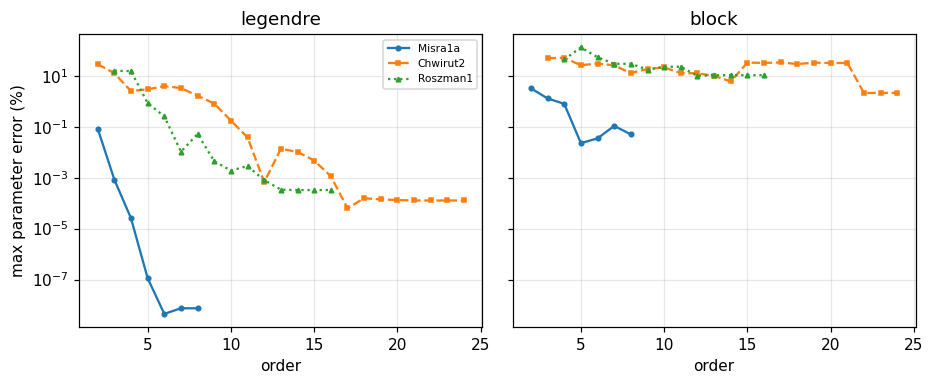

In [10]:
if not order_sweep.empty:
    fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.6), sharey=True)
    for ax, basis in zip(axes, ("legendre", "block")):
        for name, style in zip(("Misra1a", "Chwirut2", "Roszman1"), ("o-", "s--", "^:")):
            line = order_sweep[(order_sweep.dataset == name)
                                & (order_sweep.basis == basis)].sort_values("order")
            ax.semilogy(line.order, line.max_error_pct, style, label=name, markersize=3)
        ax.set_title(basis)
        ax.set_xlabel("order")
        ax.grid(True, which="both", alpha=0.3)
    axes[0].set_ylabel("max parameter error (%)")
    axes[0].legend(fontsize=7)
    fig.tight_layout()
    plt.show()


In [11]:
if QUICK or order_sweep.empty:
    print("QUICK or no data: skipping the CSV export")
else:
    notebook.save_table("31_reference_datasets", "nist_order_sweep", order_sweep)
    print("wrote experiments/results/31_reference_datasets/nist_order_sweep.csv")


wrote experiments/results/31_reference_datasets/nist_order_sweep.csv


In [12]:
if not order_sweep.empty:
    for name in ("Misra1a", "Chwirut2", "Roszman1"):
        sub = order_sweep[order_sweep.dataset == name]
        leg = sub[sub.basis == "legendre"].sort_values("order")
        k0 = int(leg.order_for.iloc[0])
        at_order_for = leg[leg.order == k0].max_error_pct.iloc[0]
        at_largest = leg.max_error_pct.iloc[-1]
        # fails if legendre's error at the largest usable order is not below its error
        # at order_for
        assert at_largest < at_order_for, name
        if name in ("Chwirut2", "Roszman1"):
            blk = sub[sub.basis == "block"].sort_values("order")
            for check_order in (2 * k0, int(sub.cap.iloc[0])):
                leg_e = leg[leg.order == check_order].max_error_pct.iloc[0]
                blk_e = blk[blk.order == check_order].max_error_pct.iloc[0]
                # fails if block's error is not at least 10x legendre's at this order
                assert blk_e >= 10 * leg_e, (name, check_order)
    print("legendre's error at the largest usable order is below its error at order_for "
          "on all three; on Chwirut2 and Roszman1 block stays at least 10x above legendre "
          "at twice order_for and at the largest usable order")


legendre's error at the largest usable order is below its error at order_for on all three; on Chwirut2 and Roszman1 block stays at least 10x above legendre at twice order_for and at the largest usable order


Legendre's error is not monotone at every step (Chwirut2 rises from order 4 to 6 before
falling again), but from `order_for` to the largest usable order it always ends up lower: on
Misra1a from 0.085 to 7.5e-9 percent, on Chwirut2 from 3.9 to 1.3e-4, on Roszman1 from 15.2 to
3.3e-4. Block does not track it down: on Chwirut2 it moves from 30.1 percent at `order_for`
to 2.1 at the cap, still four orders of magnitude above Legendre (12.5 against 0.00067 percent
at twice `order_for`, a factor of about 18600; 2.1 against 0.00013 at the cap, about 16700).
On Roszman1 block never drops below 9.9 percent in the whole sweep, against Legendre's 0.00033
at the cap - a factor above 30000. This is the loss for the block basis on these two records:
a non-uniform grid (Chwirut2) or a narrow one (Roszman1, 25 points), where the window basis
has too few points per window to average away the noise the way the global polynomial does.


## 3. The held-out tail

The first 65 percent of each record (at least twice the parameter count), forecast onto the
rest; error read against the certified curve (the model at NIST's certified parameters), not
against the noisy held-out samples, since that is the only ground truth this corpus offers.
Start 2 throughout, so the comparison is not about which start each method prefers.


In [13]:
rows = []
if NIST_DIR.is_dir():
    for name in DATASET_NAMES:
        d = reference.load(name)
        n = d.x.size
        n_params = len(d.names)
        cut = min(max(round(0.65 * n), 2 * n_params), n - 1)
        x_fit, y_fit = d.x[:cut], d.y[:cut]
        x_tail = d.x[cut:]
        if x_tail.size == 0:
            continue
        canon = sorted(d.names)
        p0 = dict(zip(d.names, d.start2))
        domain_fit = (float(x_fit.min()), float(x_fit.max()))
        f_num = sp.lambdify(
            (sp.Symbol("x"), *[sp.Symbol(n_) for n_ in d.names]), d.expr, "numpy"
        )
        cert_tail = f_num(x_tail, *d.certified)
        yrange = d.y.max() - d.y.min()

        try:
            popt, _ = curve_fit(
                f_num, x_fit, y_fit, p0=[p0[n_] for n_ in d.names], maxfev=20000
            )
            pred = f_num(x_tail, *popt)
            nrmse = 100 * np.sqrt(np.mean((pred - cert_tail) ** 2)) / yrange
            rows.append({"dataset": name, "method": "nlls", "cut": cut,
                         "n_tail": x_tail.size, "nrmse_pct": nrmse, "status": "converged"})
        except RuntimeError:
            rows.append({"dataset": name, "method": "nlls", "cut": cut,
                         "n_tail": x_tail.size, "nrmse_pct": np.nan, "status": "diverged"})

        original_fit = Original(x_fit, y_fit, domain=domain_fit)
        k0 = order_for(d.expr, [p0[n_] for n_ in canon], domain_fit, var="x")
        for basis in ("legendre", "block"):
            try:
                res = fit(d.expr, original_fit, var="x", basis=basis, order=k0, p0=p0)
                pred = res.predict(x_tail)
                nrmse = 100 * np.sqrt(np.mean((pred - cert_tail) ** 2)) / yrange
                rows.append({"dataset": name, "method": basis, "cut": cut,
                             "n_tail": x_tail.size, "nrmse_pct": nrmse,
                             "status": "converged"})
            except ValueError:
                rows.append({"dataset": name, "method": basis, "cut": cut,
                             "n_tail": x_tail.size, "nrmse_pct": np.nan, "status": "guard"})
    nist_forecast = pd.DataFrame(rows)
else:
    print(f"NIST corpus missing, skipping: {NIST_DIR}")
    nist_forecast = pd.DataFrame()
nist_forecast


,dataset,method,cut,n_tail,nrmse_pct,status
0,Misra1a,nlls,9,5,0.710337,converged
1,Misra1a,legendre,9,5,0.739155,converged
2,Misra1a,block,9,5,NaN,guard
3,DanWood,nlls,4,2,1.452747,converged
4,DanWood,legendre,4,2,1.452871,converged
5,DanWood,block,4,2,2.212274,converged
6,Chwirut2,nlls,35,19,0.664585,converged
7,Chwirut2,legendre,35,19,0.620301,converged
8,Chwirut2,block,35,19,2.809595,converged
9,Misra1c,nlls,9,5,0.312065,converged


In [14]:
if QUICK or nist_forecast.empty:
    print("QUICK or no data: skipping the CSV export")
else:
    notebook.save_table("31_reference_datasets", "nist_forecast", nist_forecast)
    print("wrote experiments/results/31_reference_datasets/nist_forecast.csv")

wrote experiments/results/31_reference_datasets/nist_forecast.csv


In [15]:
if not nist_forecast.empty:
    piv = nist_forecast.pivot_table(index="dataset", columns="method", values="nrmse_pct")
    # legendre only: block is reported separately in the reading below and is not
    # held to this bound
    both = piv.dropna(subset=["legendre", "nlls"])
    ratio = both["legendre"] / both["nlls"]
    # fails if the legendre forecast is not within 2x of the NLLS forecast on a dataset
    # where both converge
    assert (ratio < 2.0).all(), ratio[ratio >= 2.0]
    print(f"on the {len(ratio)} datasets where both converge, legendre/nlls nRMSE ratio "
          f"stays in [{ratio.min():.2f}, {ratio.max():.2f}]")

on the 9 datasets where both converge, legendre/nlls nRMSE ratio stays in [0.40, 1.04]


On the nine datasets where the Legendre forecast converges, its nRMSE against the
certified curve stays within a factor of 0.40 to 1.04 of NLLS's - closer to NLLS than to 2x
away on every one, and often the better of the two (Chwirut2 0.62 against 0.66 percent,
Roszman1 1.97 against 4.95, MGH17 0.45 against 0.91). Block's forecast is not part of that
comparison and is visibly worse where it can be built at all (Chwirut2 2.81, Rat42 19.0
against Legendre's 3.32 and NLLS's 3.38). BoxBOD is the one dataset where Legendre cannot be built at its
automatic order even for the held-out forecast (the same six-observation guard as section 1);
there NLLS and block agree with each other (25.1 and 24.1 percent) but neither is close to
the certified curve, the largest error in the table.


## 4. Puromycin: the replicate design

Michaelis-Menten `Vmax*conc/(Km+conc)` on the vendored twelve pairs (Bates and Watts 1988,
treated group), six concentrations each measured twice. A replicate pair sits at the same
`conc`, zero spacing in the design, which breaks a statistic built from a derivative or from
the spacing between neighbouring samples. The discrete image only evaluates the basis at each
sample position and needs no spacing between them, replicate or not; the question is whether
both bases recover the NLLS answer on such a design. This section always runs: the data is
vendored, not fetched.


In [16]:
conc, vel = reference.puromycin()
p0 = {"Vmax": 200.0, "Km": 0.1}
expr = "Vmax*conc/(Km+conc)"
f_num = sp.lambdify((sp.Symbol("conc"), sp.Symbol("Vmax"), sp.Symbol("Km")), sp.sympify(expr),
                     "numpy")

rows = []
for basis in ("legendre", "block"):
    res = fit(expr, Original(conc, vel), var="conc", basis=basis, p0=p0)
    pred = res.predict(conc)
    rmse = float(np.sqrt(np.mean((pred - vel) ** 2)))
    rows.append({"method": basis, "Vmax": res.params["Vmax"], "Km": res.params["Km"],
                 "image_order": res.image_order, "rmse": rmse, "r2": in_sample_r2(vel, pred)})
popt, _ = curve_fit(f_num, conc, vel, p0=[p0["Vmax"], p0["Km"]], maxfev=20000)
pred = f_num(conc, *popt)
rows.append({"method": "nlls", "Vmax": popt[0], "Km": popt[1], "image_order": np.nan,
             "rmse": float(np.sqrt(np.mean((pred - vel) ** 2))),
             "r2": in_sample_r2(vel, pred)})
puromycin = pd.DataFrame(rows).set_index("method")
puromycin

,Vmax,Km,image_order,rmse,r2
method,,,,,
legendre,212.683732,0.064121,7.0,9.981019,0.961261
block,213.908921,0.064438,8.0,10.007651,0.961054
nlls,212.683630,0.064121,NaN,9.981019,0.961261


In [17]:
if QUICK or puromycin.empty:
    print("QUICK: skipping the CSV export")
else:
    notebook.save_table("31_reference_datasets", "puromycin", puromycin.reset_index())
    print("wrote experiments/results/31_reference_datasets/puromycin.csv")

wrote experiments/results/31_reference_datasets/puromycin.csv


In [18]:
nlls_vmax = puromycin.loc["nlls", "Vmax"]
for basis in ("legendre", "block"):
    err = abs(puromycin.loc[basis, "Vmax"] - nlls_vmax) / nlls_vmax
    # fails if either image's Vmax does not recover within 10 percent of NLLS
    assert err < 0.10, basis
    # fails if either image's in-sample fit is not clearly good on the replicate design
    assert puromycin.loc[basis, "r2"] > 0.9, basis
print(f"NLLS Vmax {nlls_vmax:.1f}; legendre "
      f"{puromycin.loc['legendre', 'Vmax']:.1f} (image_order "
      f"{int(puromycin.loc['legendre', 'image_order'])}, "
      f"{abs(puromycin.loc['legendre', 'Vmax'] - nlls_vmax) / nlls_vmax * 100:.2f} percent "
      f"off), block {puromycin.loc['block', 'Vmax']:.1f} (image_order "
      f"{int(puromycin.loc['block', 'image_order'])}, "
      f"{abs(puromycin.loc['block', 'Vmax'] - nlls_vmax) / nlls_vmax * 100:.2f} percent "
      f"off); R2 legendre {puromycin.loc['legendre', 'r2']:.4f}, "
      f"block {puromycin.loc['block', 'r2']:.4f}, nlls {puromycin.loc['nlls', 'r2']:.4f}")

NLLS Vmax 212.7; legendre 212.7 (image_order 7, 0.00 percent off), block 213.9 (image_order 8, 0.58 percent off); R2 legendre 0.9613, block 0.9611, nlls 0.9613


All three methods land within 0.6 percent of each other on Vmax (NLLS and Legendre
agree to the fifth significant figure, 212.7 both; block is 213.9, 0.58 percent off) and
within 0.5 percent on Km, with R2 at 0.961 for all three. Both images carry few coefficients
for twelve samples - Legendre picks `image_order` 7, block 8 - and land at parity with NLLS
anyway. The discrete image evaluates its basis at each sample position, so a repeated
concentration is two rows with the same basis values and nothing divides by the zero spacing.
The replicate design does not tell the two bases apart.

## 5. The epidemic and the exchange rate: no ground truth, only agreement

`a*exp(b*t)` on two real series with no certified answer: COVID-19 Ukraine's cumulative
confirmed cases from the first day past 500, 24 days; and the USD/UAH daily rate, first 200
days of the 2014-15 crisis, normalised to its first value. Validity here is the three methods
agreeing and fitting well, not a comparison to a known truth.


In [19]:
covid_path = notebook.data_file("covid_ukraine_confirmed.csv")
uah_path = notebook.data_file("usd_uah_2014_2015.csv")
growth_rates = pd.DataFrame()
if covid_path and uah_path:
    expr = "a*exp(b*t)"
    rows = []

    cum = pd.read_csv(covid_path)["cumulative_confirmed"].to_numpy(float)
    start = next(i for i, v in enumerate(cum) if v >= 500)
    y = cum[start:start + 24]
    t = np.arange(y.size, dtype=float)
    p0 = {"a": float(y[0]), "b": 0.2}
    bounds = {"a": (1.0, 1e6), "b": (0.01, 2.0)}
    f_num = sp.lambdify((sp.Symbol("t"), sp.Symbol("a"), sp.Symbol("b")), sp.sympify(expr),
                         "numpy")
    for basis in ("legendre", "block"):
        res = fit(expr, Original(t, y), var="t", basis=basis, p0=p0, bounds=bounds)
        pred = res.predict(t)
        rows.append({"series": "COVID-19 UA", "method": basis, "rate_b": res.params["b"],
                     "doubling_time_days": np.log(2) / res.params["b"],
                     "r2": in_sample_r2(y, pred)})
    popt, _ = curve_fit(f_num, t, y, p0=[p0["a"], p0["b"]],
                         bounds=([1.0, 0.01], [1e6, 2.0]), maxfev=20000)
    pred = f_num(t, *popt)
    rows.append({"series": "COVID-19 UA", "method": "nlls", "rate_b": popt[1],
                 "doubling_time_days": np.log(2) / popt[1], "r2": in_sample_r2(y, pred)})

    uah = pd.read_csv(uah_path)["rate_uah_per_usd"].to_numpy(float)
    seg = uah[:200] / uah[0]
    tt = np.linspace(0.0, 1.5, seg.size)
    p0b = {"a": 1.0, "b": 0.5}
    boundsb = {"a": (0.2, 5.0), "b": (0.01, 5.0)}
    for basis in ("legendre", "block"):
        res = fit(expr, Original(tt, seg), var="t", basis=basis, p0=p0b, bounds=boundsb)
        pred = res.predict(tt)
        mape = float(np.mean(np.abs((pred - seg) / seg)) * 100)
        rows.append({"series": "USD/UAH", "method": basis, "rate_b": res.params["b"],
                     "r2": in_sample_r2(seg, pred), "mape_pct": mape})
    popt2, _ = curve_fit(f_num, tt, seg, p0=[p0b["a"], p0b["b"]],
                          bounds=([0.2, 0.01], [5.0, 5.0]), maxfev=20000)
    pred2 = f_num(tt, *popt2)
    mape2 = float(np.mean(np.abs((pred2 - seg) / seg)) * 100)
    rows.append({"series": "USD/UAH", "method": "nlls", "rate_b": popt2[1],
                 "r2": in_sample_r2(seg, pred2), "mape_pct": mape2})

    growth_rates = pd.DataFrame(rows)
growth_rates


,series,method,rate_b,doubling_time_days,r2,mape_pct
0,COVID-19 UA,legendre,0.095636,7.247767,0.989641,NaN
1,COVID-19 UA,block,0.096164,7.207984,0.989619,NaN
2,COVID-19 UA,nlls,0.095639,7.247518,0.989641,NaN
3,USD/UAH,legendre,0.296555,NaN,0.782180,5.704050
4,USD/UAH,block,0.298735,NaN,0.782126,5.681574
5,USD/UAH,nlls,0.296252,NaN,0.782180,5.707334


In [20]:
if QUICK or growth_rates.empty:
    print("QUICK or no data: skipping the CSV export")
else:
    notebook.save_table("31_reference_datasets", "growth_rates", growth_rates)
    print("wrote experiments/results/31_reference_datasets/growth_rates.csv")

wrote experiments/results/31_reference_datasets/growth_rates.csv


In [21]:
if not growth_rates.empty:
    spreads = {}
    for series in ("COVID-19 UA", "USD/UAH"):
        b = growth_rates[growth_rates.series == series].rate_b
        spread = (b.max() - b.min()) / b.median()
        # fails if the three methods do not agree on the growth rate within 5 percent
        # of their median
        assert spread < 0.05, (series, spread)
        spreads[series] = round(spread * 100, 2)
    print(growth_rates.groupby("series").rate_b.agg(["median", "min", "max"]))
    print(growth_rates.groupby("series").r2.agg(["min", "max"]))
    print(f"rate_b spread as a percent of the median: {spreads}")

               median       min       max
series                                   
COVID-19 UA  0.095639  0.095636  0.096164
USD/UAH      0.296555  0.296252  0.298735
                  min       max
series                         
COVID-19 UA  0.989619  0.989641
USD/UAH      0.782126  0.782180
rate_b spread as a percent of the median: {'COVID-19 UA': np.float64(0.55), 'USD/UAH': np.float64(0.84)}


COVID-19's three growth rates sit within 0.6 percent of their median (0.0956 to 0.0962),
a doubling time of 7.2 days from every method, and R2 above 0.989 for all three - the
exponential model fits this early window well and the methods agree tightly. USD/UAH's three
rates agree less closely (0.84 percent of the median, against COVID's 0.55), and R2 is only
0.782 with MAPE about 5.7 percent for every method: a pure exponential is a mediocre fit to
the whole 200-day window of a crisis that was not smooth throughout, and the wider spread
between methods there tracks the worse fit, not just three routes agreeing on a bad model to
the same degree. Where there is no certified answer, three independent routes landing close to
the same number is the most this section can offer, and each series carries the fit quality it
was read with.

## Findings and limits

The image restriction is not helpless where the NLLS baseline fails from a bad start. On both
MGH17 and BoxBOD curve_fit's divergence from Start 1 is an artifact of the solver call and not
a wrong optimum of the problem - on MGH17 curve_fit returns `p0` unchanged, on BoxBOD it stops
on a flat plateau, and a trust-region `least_squares` from the same start reaches the certified
parameters at the certified residual cost on both - and a fixed Legendre order recovers both
well under 1 percent even though the automatic default guards on them (too large for either
record). The order has to be picked near the top of the buildable range: 10 of MGH17's 28
buildable orders and 1 of BoxBOD's 4 are themselves above 100 percent off, see above. What the
restriction changes is what a short record can identify at all: Legendre needs more
coefficients than four of the ten datasets hold at some order or start, and refuses rather than
returning a number: BoxBOD at both orders from both starts, MGH17 from Start 1, Eckerle4 from
Start 2, and Rat42 at twice `order_for` from both starts. Block, needing one fewer coefficient
per unit of accuracy on these small records, answers alone on two of those rows (BoxBOD and
Eckerle4 from Start 2) while Legendre answers alone on three others (MGH10, Misra1a and Misra1c
from Start 1). Where both build at twice `order_for`, block's error runs from 19.5x Legendre's
(Eckerle4 from Start 1) to 2.46e6x (DanWood from Start 2). Block is also not held to the
convergence half of claim 1: its error rises rather than falls with order on DanWood (both
starts) and on MGH17 from Start 2.

Puromycin does not separate the two bases: both land within 0.6 percent of NLLS. Replicate
measurements at one concentration cost the discrete image nothing, so the section reads as a
design the method handles, not as a gap.

Limits: the corpus is ten datasets NIST chose to span three difficulty levels, not a random
sample of nonlinear regression problems; "converges" here means max parameter error under 100
percent, a coarse line; the held-out tail is compared against the certified curve rather than
noisy held-out samples, which is generous to whichever method matches the true curve's shape
and less informative about sampling noise; the growth-rate section has no ground truth at
all, so agreement between methods is the only evidence offered, not proof of the true rate;
and section 3's factor-of-two forecast claim covers only the Legendre image, not block, which
exceeds it on Rat42 and Chwirut2.

In [22]:
print(notebook.provenance(STARTED))


2026-09-21 commit d3e267d dtfit 0.4.0 dtfit-experimental 0.1.0 2.9s
